In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
#load the data 
user=pd.read_csv("C:/Users/use/Desktop/user_table.csv")
session=pd.read_csv("C:/Users/use/Desktop/session_table.csv")
scroll=pd.read_csv("C:/Users/use/Desktop/scroll_table.csv")
pageview=pd.read_csv("C:/Users/use/Desktop/pageview_table.csv")
order=pd.read_csv("C:/Users/use/Desktop/order_table.csv")
order_line=pd.read_csv("C:/Users/use/Desktop/order_line_item_table.csv")
click=pd.read_csv("C:/Users/use/Desktop/click_table.csv")
add_cart=pd.read_csv("C:/Users/use/Desktop/add_to_cart_table.csv")

In [37]:
print(user.info())
#no null values 
print(user.duplicated().sum())
#no duplicates 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102435 entries, 0 to 102434
Data columns (total 3 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   user_id                 102435 non-null  object
 1   has_purchase_last_year  102435 non-null  bool  
 2   has_purchase_last_qtr   102435 non-null  bool  
dtypes: bool(2), object(1)
memory usage: 1000.5+ KB
None
0


In [57]:
user["charmed"] = np.where(
    (user["has_purchase_last_year"] == True) & (user["has_purchase_last_qtr"] == True),
    "Frequent",
    np.where(
        (user["has_purchase_last_year"] == False) & (user["has_purchase_last_qtr"] == False),
        "not_purchased","no"))                                       

charmed
not_purchased    0.89405
Frequent         0.10595
Name: proportion, dtype: float64

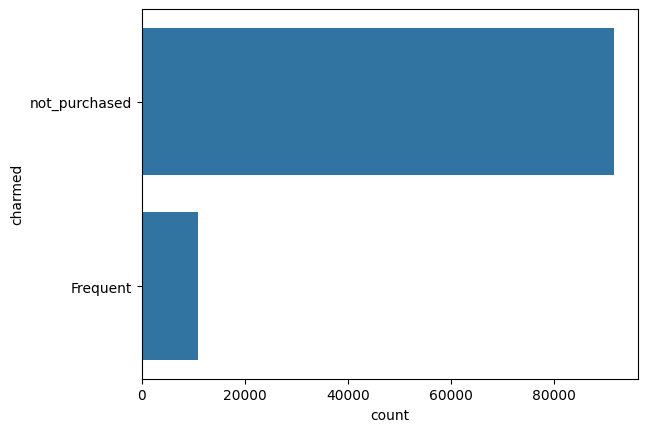

In [59]:
sns.countplot(user["charmed"])
user["charmed"].value_counts(normalize=True)
#as we can see majority of the user have not purchased our product approx 89% of them 

In [69]:
session.info()
#includenull values
session.duplicated().sum()
#include no duplicates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146000 entries, 0 to 145999
Data columns (total 17 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   user_id             146000 non-null  object 
 1   session_id          146000 non-null  object 
 2   time                146000 non-null  object 
 3   platform            146000 non-null  object 
 4   device_type         146000 non-null  object 
 5   country             146000 non-null  object 
 6   region              146000 non-null  object 
 7   city                146000 non-null  object 
 8   IP                  146000 non-null  object 
 9   referrer            99793 non-null   object 
 10  landing_page        146000 non-null  object 
 11  landing_page_query  134819 non-null  object 
 12  landing_page_hash   0 non-null       float64
 13  browser             146000 non-null  object 
 14  utm_source          134819 non-null  object 
 15  utm_medium          146000 non-nul

np.int64(0)

In [70]:
session=session.drop(columns=["landing_page_hash","region","city"],axis=1)

In [ ]:
#removed column landing page hash because all null values 
#removed cityand region because it had missed match entry so i took only country .

In [73]:
#converting data type 
session["time"]=pd.to_datetime(session["time"])

In [81]:
session.describe(include=object).T
#the device type used most is dekstop 
#the country with most session is us 
#the most referrer is google
#the broswer used most is safari
#the medium thst led to the session is paid scoial 
# the utm campagin is brand 

,count,unique,top,freq
user_id,146000,102435,15bac640-1608-49a7-8b3a-78d39cc5a779,10
session_id,146000,146000,a32f32ca-14ed-44d5-afb4-070d082e88e7,1
platform,146000,1,web,146000
device_type,146000,2,desktop,73132
country,146000,2,US,101929
IP,146000,145342,10.13.202.171,3
referrer,99793,14,google.com,18831
landing_page,146000,4,/products/ring-alarm-8-piece,36779
landing_page_query,134819,39122,utm_source=twilio&utm_medium=sms&utm_campaign=...,2297
browser,146000,3,Safari,48775


In [93]:
session.groupby('device_type')['session_id'].count()

device_type
desktop    73132
mobile     72868
Name: session_id, dtype: int64

In [98]:
#timepattern analysis
session['hour'] = pd.to_datetime(session['time']).dt.hour
session['day_of_week'] = pd.to_datetime(session['time']).dt.day_name()
session['month'] = pd.to_datetime(session['time']).dt.month

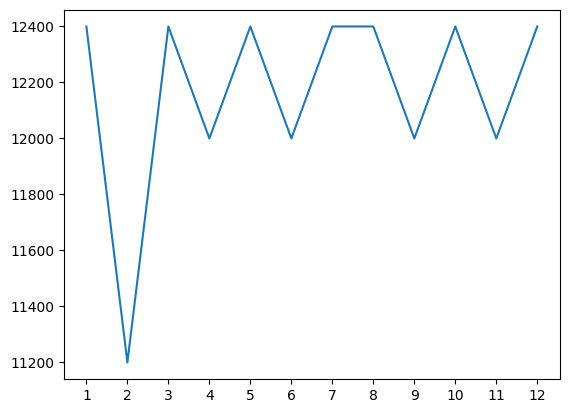

In [107]:
plt.plot(session.groupby("month")["session_id"].count())
plt.xticks(np.arange(1,13))
plt.show()
#the main reason for the reduce in trafic in the month os 2 is due to less investment in affliate 
#from the analysis it is clear that wehn the investment in the affilate is less then in that month traffic decresae 

In [109]:
#with proof
for i in range(1,13):
    se=session[session["month"]==i]
    print(se["utm_medium"].value_counts())

utm_medium
paid_social    4765
email          1935
sms             989
internal        977
display         975
organic         962
affiliate       915
cpc             882
Name: count, dtype: int64
utm_medium
paid_social    4320
email          1727
internal        893
cpc             872
organic         867
display         847
affiliate       840
sms             834
Name: count, dtype: int64
utm_medium
paid_social    4776
email          1915
affiliate      1020
cpc             984
sms             952
display         928
internal        915
organic         910
Name: count, dtype: int64
utm_medium
paid_social    4543
email          1835
sms             991
display         962
organic         931
cpc             919
internal        918
affiliate       901
Name: count, dtype: int64
utm_medium
paid_social    4714
email          1897
cpc            1001
display         979
affiliate       971
organic         957
sms             941
internal        940
Name: count, dtype: int64
utm_medium
paid

In [119]:
#hourly analysis 
for i in session["day_of_week"].unique():
    week=session[session["day_of_week"]==i]
    print(i)
    print(week["hour"].value_counts())
#wednesday the top traffic is in the hur 10,7,6,17,1
#Thursday the top traffic is in the hur 8,18,13,21,14
#friday the top traffic hour is 23,22,12,10,14
#saturday the top traffic hour is 7,4,13,14,19,0
#sunday the top traffic hour is 16,1,14,21,13,0
#monday the top traffic hour is 23,19,6,3,5,15

Wednesday
hour
10    969
7     933
6     932
17    927
1     905
16    905
20    905
11    898
19    893
9     891
8     889
2     887
0     886
22    883
21    871
5     864
14    862
4     856
23    849
12    849
15    848
18    843
3     837
13    818
Name: count, dtype: int64
Thursday
hour
8     957
18    932
13    920
21    900
14    893
15    882
3     876
11    874
22    868
17    864
2     862
6     861
12    860
23    859
5     854
10    853
19    851
4     846
16    846
7     842
1     830
20    825
9     823
0     822
Name: count, dtype: int64
Friday
hour
23    913
22    910
12    895
10    894
14    887
1     883
19    882
18    880
5     879
17    878
3     876
6     875
4     872
13    870
7     868
2     852
11    847
16    846
15    842
20    841
9     839
0     836
8     828
21    807
Name: count, dtype: int64
Saturday
hour
7     915
4     906
13    904
14    903
19    901
0     892
5     890
18    890
12    887
17    883
20    867
15    866
1     859
8     858
23    8

In [124]:
for i in session["utm_medium"].unique():
    med=session[session["utm_medium"]==i]
    print(i)
    print(med["hour"].value_counts())
#for affilate the most traffic we get it is in 21,16,22,12,7
#fot internal the most traffic we get is 5,17,12,13,4
#for paid social the most traffic 1,17,10,0,8
#for organic the most traffic is 23,10,14,8,2
#for display the most traffic is 19,3,6,5,20
#for email the most traffic we get in 21,5,22,16,7
#for sms we get the most traffic in 2,20,15,14,23
#for cpc the most traffic we et in 15,13,11,23,8

affiliate
hour
21    504
16    483
22    483
12    482
7     482
14    480
20    479
18    478
13    477
23    473
11    469
10    468
15    467
17    465
4     464
3     461
19    459
5     458
8     458
2     453
1     448
6     447
0     437
9     436
Name: count, dtype: int64
internal
hour
5     499
17    496
12    495
13    489
4     486
19    484
6     477
16    477
23    475
11    468
0     468
14    467
15    466
8     464
10    461
22    457
2     454
1     453
7     443
9     440
21    438
20    436
18    429
3     425
Name: count, dtype: int64
paid_social
hour
1     2422
17    2398
10    2378
0     2369
8     2369
19    2368
7     2355
20    2354
16    2351
12    2349
14    2345
13    2336
6     2336
2     2324
5     2322
22    2316
18    2307
4     2306
15    2294
9     2292
3     2288
21    2263
11    2256
23    2232
Name: count, dtype: int64
organic
hour
23    509
10    508
14    494
8     494
2     493
13    487
3     483
15    480
20    474
19    473
18    473
0     470

In [92]:
session[["referrer","utm_source","utm_medium","utm_campaign"]].head(30)

,referrer,utm_source,utm_medium,utm_campaign
0,impact.com,impact,affiliate,holiday_sale
1,ring.com,ring.com,internal,remarketing
2,linkedin.com,linkedin,paid_social,NaN
3,link.shortener,tiktok,paid_social,launch_q4
4,NaN,tiktok,paid_social,NaN
5,NaN,NaN,organic,remarketing
6,google.com,dv360,display,NaN
7,NaN,tiktok,paid_social,brand
8,facebook.com,facebook,paid_social,holiday_sale
9,facebook.com,facebook,paid_social,launch_q4


In [139]:
#product wise analyse
def product(x):
    return x[10:]

In [136]:
session["product_name"]=session["landing_page"].apply(product)

In [141]:
for i in session["product_name"].unique():
    med=session[session["product_name"]==i]
    print(i)
    print(med["utm_medium"].value_counts())
#for video doorbell the best medium is paid social , email , cpc ,sms
#for stick up cam battery the best medium is paid social,email,organic,affiliate
# for ring-alarm-8-piece the best medium is paid,scoial,email, display,internal
# for indoor cam the best medium is paid ,social, email,cpc,siaplay

video-doorbell-pro-2
utm_medium
paid_social    14167
email           5592
cpc             2916
sms             2876
organic         2827
affiliate       2818
internal        2777
display         2769
Name: count, dtype: int64
stick-up-cam-battery
utm_medium
paid_social    13984
email           5586
organic         2841
affiliate       2811
sms             2807
display         2773
cpc             2738
internal        2722
Name: count, dtype: int64
ring-alarm-8-piece
utm_medium
paid_social    14056
email           5729
display         2903
internal        2871
affiliate       2858
cpc             2841
sms             2783
organic         2738
Name: count, dtype: int64
indoor-cam-(2nd-gen)
utm_medium
paid_social    13723
email           5630
cpc             2902
display         2854
sms             2832
internal        2777
organic         2775
affiliate       2724
Name: count, dtype: int64


In [148]:
pageview.info()
#include null values
pageview.duplicated().sum()
#no duplicates 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 354456 entries, 0 to 354455
Data columns (total 9 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_id       354456 non-null  object 
 1   user_id        354456 non-null  object 
 2   session_id     354456 non-null  object 
 3   time           354456 non-null  object 
 4   domain         354456 non-null  object 
 5   path           354456 non-null  object 
 6   hash           0 non-null       float64
 7   query          134819 non-null  object 
 8   previous_page  208456 non-null  object 
dtypes: float64(1), object(8)
memory usage: 24.3+ MB


np.int64(0)

In [149]:
#removing columns 
pageview=pageview.drop(columns="hash",axis=1)

In [178]:
click.info()
#include nulls

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 204752 entries, 0 to 204751
Data columns (total 13 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   event_id       204752 non-null  object 
 1   user_id        204752 non-null  object 
 2   session_id     204752 non-null  object 
 3   time           204752 non-null  object 
 4   domain         204752 non-null  object 
 5   path           204752 non-null  object 
 6   hash           0 non-null       float64
 7   query          0 non-null       float64
 8   href           0 non-null       float64
 9   target_id      204752 non-null  object 
 10  target_tag     204752 non-null  object 
 11  target_text    204752 non-null  object 
 12  previous_page  146319 non-null  object 
dtypes: float64(3), object(10)
memory usage: 20.3+ MB


In [179]:
#dropping columns 
click=click.drop(columns=["hash","query","href"],axis=1)

In [184]:
scroll.info()
#include some null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 292106 entries, 0 to 292105
Data columns (total 10 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   event_id        292106 non-null  object 
 1   user_id         292106 non-null  object 
 2   session_id      292106 non-null  object 
 3   time            292106 non-null  object 
 4   scroll_percent  292106 non-null  int64  
 5   domain          292106 non-null  object 
 6   path            292106 non-null  object 
 7   hash            0 non-null       float64
 8   query           0 non-null       float64
 9   previous_page   208664 non-null  object 
dtypes: float64(2), int64(1), object(7)
memory usage: 22.3+ MB


In [185]:
#dropping columns
scroll=scroll.drop(columns=["hash","query"],axis=1)

In [189]:
add_cart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25133 entries, 0 to 25132
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   event_id       25133 non-null  object 
 1   user_id        25133 non-null  object 
 2   session_id     25133 non-null  object 
 3   time           25133 non-null  object 
 4   domain         25133 non-null  object 
 5   path           25133 non-null  object 
 6   hash           0 non-null      float64
 7   query          0 non-null      float64
 8   previous_page  25133 non-null  object 
 9   product_name   25133 non-null  object 
 10  product_price  25133 non-null  float64
 11  product_qty    25133 non-null  int64  
dtypes: float64(3), int64(1), object(8)
memory usage: 2.3+ MB


In [190]:
add_cart=add_cart.drop(columns=["hash","query"],axis=1)

In [199]:
order.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11206 entries, 0 to 11205
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   event_id              11206 non-null  object 
 1   user_id               11206 non-null  object 
 2   session_id            11206 non-null  object 
 3   order_id              11206 non-null  object 
 4   time                  11206 non-null  object 
 5   total_price           11206 non-null  float64
 6   shipping_price        11206 non-null  int64  
 7   discount              11206 non-null  int64  
 8   discount_coupon_code  7555 non-null   object 
 9   total_items           11206 non-null  int64  
 10  total_qty             11206 non-null  int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 963.1+ KB


In [281]:
order["discount_given"]=np.where(order["discount"]>0,"dicount_given","not_given")
order["time"]=pd.to_datetime(order["time"])
order["month"]=order["time"].dt.month

In [205]:
order["discount_given"].value_counts()
#majority of purchase happens when discount is given 

discount_given
dicount_given    7512
not_given        3694
Name: count, dtype: int64

In [211]:
order_line=order_line.merge(right=order[["session_id","discount"]],on="session_id",how="left")

In [227]:
order_line["time"]=pd.to_datetime(order_line["time"])

In [228]:
order_line["month"]=order_line["time"].dt.month

In [215]:
order_line["total_price"]=order_line["product_price"]-(order_line["product_price"]*order_line["discount"])/100

In [220]:
print(f"the total revenue is {order_line["total_price"].sum()}")
print(f"the total quantity is {order_line["product_qty"].sum()}")

the total revenue is 3332281.449
the total quantity is 33600


In [242]:
#based on product 
print(order_line.groupby("product_name")["total_price"].sum().reset_index().sort_values(by="total_price",ascending=False))
print(order_line.groupby("product_name")["product_qty"].sum().reset_index().sort_values(by="product_qty",ascending=False))

           product_name  total_price
3  Video Doorbell Pro 2  1267424.301
1    Ring Alarm 8-piece  1262049.516
2  Stick Up Cam Battery   501699.825
0  Indoor Cam (2nd Gen)   301107.807
           product_name  product_qty
3  Video Doorbell Pro 2         8462
1    Ring Alarm 8-piece         8394
2  Stick Up Cam Battery         8374
0  Indoor Cam (2nd Gen)         8370


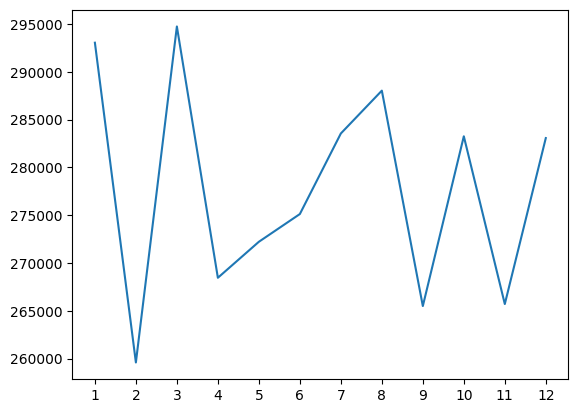

In [239]:
plt.plot(order_line.groupby("month")["total_price"].sum())
plt.xticks(np.arange(1,13))
plt.show()
#the month in which the discount was given less in that month the sales decrease as the people puchase reduce 

In [243]:
sessions = session["session_id"].nunique()
cart_sessions = add_cart["session_id"].nunique()
order_sessions = order["session_id"].nunique()

print("\n=== FUNNEL ===")
print("Sessions:", sessions)
print("Add to Cart:", cart_sessions)
print("Orders:", order_sessions)

print("\nConversion Rates")
print("Session → Cart:", round(cart_sessions/sessions*100,2), "%")
print("Cart → Order:", round(order_sessions/cart_sessions*100,2), "%")
print("Session → Order:", round(order_sessions/sessions*100,2), "%")


=== FUNNEL ===
Sessions: 146000
Add to Cart: 25133
Orders: 11206

Conversion Rates
Session → Cart: 17.21 %
Cart → Order: 44.59 %
Session → Order: 7.68 %


In [249]:
df = session.copy()

df["added_to_cart"] = df["session_id"].isin(add_cart["session_id"])
df["ordered"] = df["session_id"].isin(order["session_id"])

# scroll depth per session
scroll_depth = scroll.groupby("session_id")["scroll_percent"].max().reset_index()
df = df.merge(scroll_depth, on="session_id", how="left")

In [256]:
#analyse by utm_medium
source_drop = df.groupby("utm_medium").agg(
    sessions=("session_id","count"),
    cart_rate=("added_to_cart","mean"),
    purchase_rate=("ordered","mean")
).sort_values("purchase_rate")
print(source_drop)
#as we can see sms have the highest converstion rate where 7.9% percent is converted 
#the least conversation rate is of organic 

             sessions  cart_rate  purchase_rate
utm_medium                                     
organic         11181   0.172435       0.073875
cpc             11397   0.168641       0.075897
paid_social     55930   0.171929       0.075970
email           22537   0.171851       0.077073
display         11299   0.171785       0.077617
affiliate       11211   0.172598       0.078138
internal        11147   0.174576       0.078317
sms             11298   0.174544       0.079926


In [265]:
#analyse by tum_sourse
for i in df["product_name"].unique():
    print(i)
    new=df[df["product_name"]==i]
    source_drop = new.groupby("utm_medium").agg(
    sessions=("session_id","count"),
    cart_rate=("added_to_cart","mean"),
    purchase_rate=("ordered","mean")
    ).sort_values(by="purchase_rate",ascending=False)
    print(source_drop)
#for video doorbell the best medium is sms and worst is internal 
#for stick up cam battery the best medium is display and worst is cpc
#for ring alarm 8 piece the best medium is sms and worst is organic 
#for indoor cam the best is affiliate and worst is display

video-doorbell-pro-2
             sessions  cart_rate  purchase_rate
utm_medium                                     
sms              2876   0.174548       0.083102
cpc              2916   0.165295       0.078875
affiliate        2818   0.171753       0.078779
paid_social     14167   0.168561       0.076586
organic          2827   0.173329       0.076406
display          2769   0.159986       0.074395
email            5592   0.165236       0.074392
internal         2777   0.167447       0.073821
stick-up-cam-battery
             sessions  cart_rate  purchase_rate
utm_medium                                     
display          2773   0.186080       0.083303
sms              2807   0.180620       0.078732
internal         2722   0.174504       0.078251
organic          2841   0.181978       0.077086
email            5586   0.166309       0.075367
paid_social     13984   0.173269       0.074800
affiliate        2811   0.168268       0.073995
cpc              2738   0.164354       0.07341

In [267]:
df["purchased"]=np.where((df["added_to_cart"]==False)&(df["ordered"]==False),"no step",
                         np.where((df["added_to_cart"]==True)&(df["ordered"]==True),"purchased","added_cart"))

In [284]:
df.groupby('device_type').agg(
    sessions=('session_id','count'),
    cart_rate=('added_to_cart','mean'),
    purchase_rate=('ordered','mean')
)
#"No significant difference in conversion rate between desktop and mobile, 
#suggesting the mobile experience is well-optimized — or that both audiences have similar intent levels."

,sessions,cart_rate,purchase_rate
device_type,,,
desktop,73132,0.171457,0.076916
mobile,72868,0.172833,0.076591


In [301]:
#click analysis
print(click['target_text'].value_counts())
buy_now_sessions = click[click['target_text']=='Buy Now']['session_id'].unique()
df['clicked_buy_now'] = df['session_id'].isin(buy_now_sessions)
print(df.groupby('clicked_buy_now')['ordered'].mean())
#the more the user clicks the more chance of hsi or her to purchase 

target_text
Buy Now        68593
Add to Cart    68391
Learn More     67768
Name: count, dtype: int64
clicked_buy_now
False    0.048763
True     0.134679
Name: ordered, dtype: float64


In [294]:
#scroll percent analyse
df.groupby('purchased')['scroll_percent'].mean()
#"Scroll depth is uniform across converting and non-converting sessions, suggesting engagement depth alone does not predict purchase intent."

purchased
added_cart    85.453690
no step       85.630657
purchased     85.730701
Name: scroll_percent, dtype: float64

In [309]:
l=pageview.groupby("session_id")["time"].max().reset_index()

In [310]:
l[l["session_id"]=="eb94ac76-0e7c-42bb-a6a3-4014bd8b7906"]

,session_id,time
134141,eb94ac76-0e7c-42bb-a6a3-4014bd8b7906,2025-12-31 06:18:06


In [312]:
new_page=pageview.merge(right=l,on="session_id",how="left")

In [315]:
new_page=new_page[new_page["time_x"]==new_page["time_y"]]

In [322]:
product_sessions = new_page[new_page["path"].str.contains("/products/")]["session_id"].nunique()
category_sessions = new_page[new_page["path"].str.contains("/category/")]["session_id"].nunique()
checkout_sessions = new_page[new_page["path"].str.contains("/checkout/payment")]["session_id"].nunique()
thankyou_sessions = new_page[new_page["path"].str.contains("/checkout/thankyou")]["session_id"].nunique()
cart= new_page[new_page["path"].str.contains("/cart")]["session_id"].nunique()
print("Product Page:   ", product_sessions)
print("Add to Cart:    ", cart)
print("Checkout:       ", checkout_sessions)
print("Purchased:      ", thankyou_sessions)
print("category:      ", category_sessions)
#The funnel has one dominant problem — 43% of all sessions end on the product page. Everything after that is remarkably healthy. 
#Category → Cart → Checkout → Purchase all have similar volumes (~20-21K each) meaning once a user moves past the product page,
#they almost always complete the purchase.

Product Page:    62649
Add to Cart:     20693
Checkout:        21021
Purchased:       20811
category:       20826


In [337]:
funnel_data = pd.DataFrame({
    'stage': ['All Sessions', 'Product Page', 'Category Page', 'Cart', 'Checkout', 'Purchased'],
    'sessions': [146000, 62649, 20826, 20693, 21021, 20811],
    'order': [1, 2, 3, 4, 5, 6]
})


In [324]:
order["real_price"]=order["total_price"]-(order["total_price"]*order["discount"])/100

In [327]:
order=order.merge(right=session[["session_id","country","device_type","utm_medium"]],on="session_id",how="left")

In [329]:
order=order.drop(columns="discount_coupon_code",axis=1)

In [343]:
session=session.merge(right=df[["session_id","purchased"]],on="session_id",how="left")

In [341]:
session=session[["session_id","product_name","utm_medium","month","hour"]]

In [330]:
channel_perf = df.groupby('utm_medium').agg(
    sessions=('session_id','count'),
    cart_rate=('added_to_cart','mean'),
    purchase_rate=('ordered','mean')
).reset_index()

In [338]:
funnel_data.to_csv("C:/Users/use/Music/funnel.csv",index=False)

In [344]:
order.to_csv("C:/Users/use/Music/new_order.csv",index=False)
order_line.to_csv("C:/Users/use/Music/new_order_line.csv",index=False)
session.to_csv("C:/Users/use/Music/new_session.csv",index=False)
channel_perf.to_csv("C:/Users/use/Music/channel.csv",index=False)